Business Problem

A telecom company wants to predict whether a customer will leave (churn) or stay.

Target Variable:

Churn

0 = Stay
1 = Leave

Features:

Age
MonthlyCharges
Tenure
SupportTickets
InternetUsage

Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)


Cell 2: Generate Realistic Dataset

In [2]:
np.random.seed(42)

n = 2000

age = np.random.randint(18, 70, n)

monthly_charges = np.random.randint(500, 5000, n)

tenure = np.random.randint(1, 72, n)

support_tickets = np.random.randint(0, 10, n)

internet_usage = np.random.randint(50, 1000, n)

churn = (
    (monthly_charges > 3500).astype(int)
    + (support_tickets > 5).astype(int)
    + (tenure < 12).astype(int)
)

churn = (churn >= 2).astype(int)

df = pd.DataFrame({
    "Age": age,
    "MonthlyCharges": monthly_charges,
    "Tenure": tenure,
    "SupportTickets": support_tickets,
    "InternetUsage": internet_usage,
    "Churn": churn
})

df.head()

,Age,MonthlyCharges,Tenure,SupportTickets,InternetUsage,Churn
0,56,4944,41,9,987,1
1,69,1459,49,0,737,0
2,46,1192,49,6,445,0
3,32,4399,71,5,657,0
4,60,4973,3,6,906,1


Cell 3: Basic Checks

In [6]:
print(df.shape)
print("\n")
print("\n",df.info())
print("\n",df.describe())
print("\n",df.isnull().sum())


(2000, 6)


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             2000 non-null   int64
 1   MonthlyCharges  2000 non-null   int64
 2   Tenure          2000 non-null   int64
 3   SupportTickets  2000 non-null   int64
 4   InternetUsage   2000 non-null   int64
 5   Churn           2000 non-null   int64
dtypes: int64(6)
memory usage: 93.9 KB

 None

                Age  MonthlyCharges       Tenure  SupportTickets  \
count  2000.000000       2000.0000  2000.000000     2000.000000   
mean     43.805500       2765.9530    36.595500        4.564500   
std      14.929203       1284.4169    20.317659        2.909652   
min      18.000000        501.0000     1.000000        0.000000   
25%      31.000000       1635.7500    19.000000        2.000000   
50%      44.000000       2793.0000    37.000000        5.000000   
75%      56.000000       3904.00

Cell 4: Target Distribution

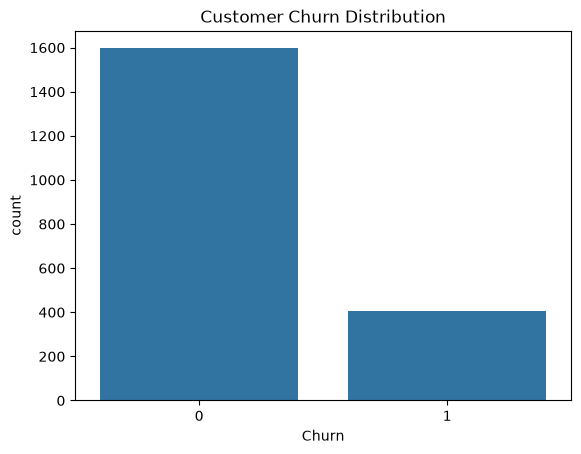

In [7]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

Cell 5: Correlation

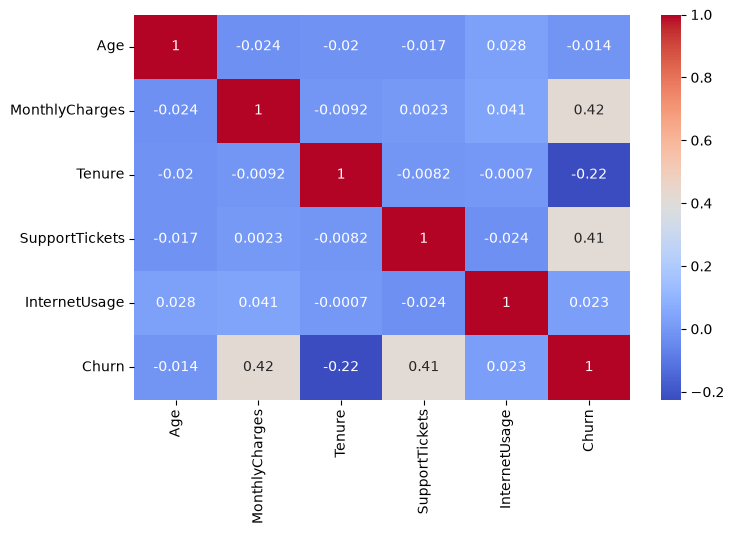

In [8]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Cell 6: Features and Target

In [9]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print(X)
print("\n")
print(y)

      Age  MonthlyCharges  Tenure  SupportTickets  InternetUsage
0      56            4944      41               9            987
1      69            1459      49               0            737
2      46            1192      49               6            445
3      32            4399      71               5            657
4      60            4973       3               6            906
...   ...             ...     ...             ...            ...
1995   63            2869      57               9            376
1996   67            1017      69               6            969
1997   69            1841      61               0            752
1998   24            2488       2               8            519
1999   20            4045      55               6            542

[2000 rows x 5 columns]


0       1
1       0
2       0
3       0
4       1
       ..
1995    0
1996    0
1997    0
1998    1
1999    1
Name: Churn, Length: 2000, dtype: int64


Cell 7: Train Test Split


Why stratify?
Maintains same class ratio in train and test data


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Cell 8: Feature Scaling

Very Important for Logistic Regression.


Why StandardScaler?

Logistic Regression is distance/optimization based.
Scaling helps gradient convergence.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Cell 9: Train Logistic Regression

In [12]:
model = LogisticRegression()

model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

Cell 10: Predictions

In [13]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:,1]

print(y_pred,"\n", y_prob)

[0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 1
 0 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1
 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0] 
 [6.83385879e-02 7.64226226e-01 1.42994918e-02 3.62546183e-05
 1.06495454e-02 6.78173973e-03 3.59694775e-03 9.05910188e-01
 3.64420083e-02 2.47268236e-02 3.23712200e-01 1.08765183e-02
 5.

Cell 11: Accuracy

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy,4))

Accuracy: 0.8825


Cell 12: Confusion Matrix

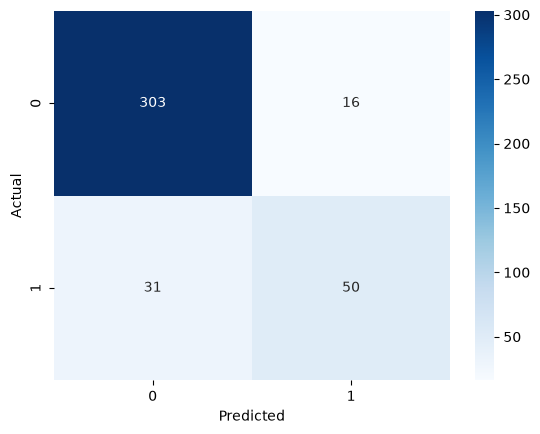

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Cell 13: Precision

In [16]:
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", precision)

Precision: 0.7575757575757576


Cell 14: Recall

In [17]:
recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", recall)

Recall: 0.6172839506172839


Cell 15: F1 Score

In [18]:
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", f1)

F1 Score: 0.6802721088435374


Cell 16: ROC-AUC

In [19]:
auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC AUC:", auc)

ROC AUC: 0.93049266612485


Cell 17: Full Report

In [20]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       319
           1       0.76      0.62      0.68        81

    accuracy                           0.88       400
   macro avg       0.83      0.78      0.80       400
weighted avg       0.88      0.88      0.88       400



Cell 18: ROC Curve

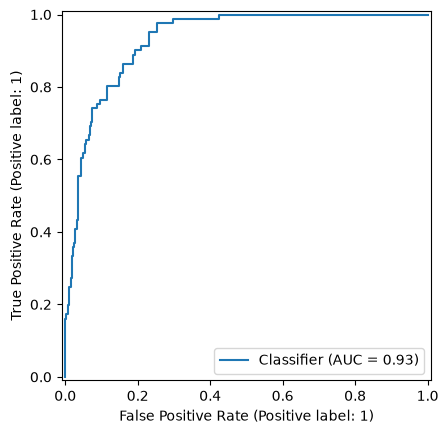

In [21]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.show()

Cell 19: Feature Importance

Logistic Regression coefficients.

In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance.sort_values(
    by="Coefficient",
    ascending=False,
    inplace=True
)

importance

,Feature,Coefficient
3,SupportTickets,2.390709
1,MonthlyCharges,2.215364
0,Age,0.046951
4,InternetUsage,0.013608
2,Tenure,-1.208417


Cell 20: Hyperparameter Tuning

In [23]:
from sklearn.model_selection import GridSearchCV

params = {
    "C":[0.01,0.1,1,10],
    "penalty":["l1","l2"],
    "solver":["liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(),
    params,
    cv=5,
    scoring="f1"
)

grid.fit(
    X_train_scaled,
    y_train
)

print(grid.best_params_)

/Users/ra20549220/Desktop/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ra20549220/Desktop/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ra20549220/Desktop/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or '

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


/Users/ra20549220/Desktop/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ra20549220/Desktop/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/ra20549220/Desktop/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or '

Cell 21: Train Best Model

In [25]:
best_model = grid.best_estimator_

best_model.fit(
    X_train_scaled,
    y_train
)

best_model.score(
    X_test_scaled,
    y_test
)

/Users/ra20549220/Desktop/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ra20549220/Desktop/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


0.8825

In [26]:
y_pred = best_model.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8825
Precision: 0.7575757575757576
Recall   : 0.6172839506172839
F1 Score : 0.6802721088435374


Cell 22: Predict New Customer

In [27]:
new_customer = pd.DataFrame({
    "Age":[28],
    "MonthlyCharges":[4500],
    "Tenure":[5],
    "SupportTickets":[8],
    "InternetUsage":[900]
})

In [28]:
print(new_customer)

   Age  MonthlyCharges  Tenure  SupportTickets  InternetUsage
0   28            4500       5               8            900


In [29]:
new_scaled = scaler.transform(
    new_customer
)
prediction = best_model.predict(
    new_scaled
)

probability = best_model.predict_proba(
    new_scaled
)[0][1]

print("Churn Prediction:", prediction[0])
print("Probability:", round(probability*100,2), "%")

Churn Prediction: 1
Probability: 98.67 %
